In [88]:
import numpy as np 
import pandas as pd 
import os 
import matplotlib.pyplot as plt
def load_kaggle_data(filename, dataset_slug):
    """
    Automatically detects the environment and loads a CSV file 
    using either the local path or the Kaggle server path.
    
    Parameters:
    - filename (str): The name of the file (e.g., 'patients.csv')
    - dataset_slug (str): The dataset folder name used on Kaggle (e.g., 'username/dataset_name')
    """

    kaggle_path = os.path.join('/kaggle/input/datasets/', dataset_slug, filename)
  
    if os.path.exists(kaggle_path):
        print(f"✈️ Running on Kaggle. Loading: {kaggle_path}")
        return pd.read_csv(kaggle_path,sep="\t")
    else:
        print(f"🏠 Running locally. Loading: {filename}")
        return pd.read_csv('../data/'+filename,sep="\t")

data = load_kaggle_data("marketing_campaign.csv","imakash3011/customer-personality-analysis")

🏠 Running locally. Loading: marketing_campaign.csv


In [89]:
data.dtypes

ID                       int64
Year_Birth               int64
Education                  str
Marital_Status             str
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer                str
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
AcceptedCmp3             int64
AcceptedCmp4             int64
AcceptedCmp5             int64
AcceptedCmp1             int64
AcceptedCmp2             int64
Complain                 int64
Z_CostContact            int64
Z_Revenue                int64
Response                 int64
dtype: object

In [90]:
data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


### Products
* MntWines: Amount spent on wine in last 2 years
* MntFruits: Amount spent on fruits in last 2 years
* MntMeatProducts: Amount spent on meat in last 2 years
* MntFishProducts: Amount spent on fish in last 2 years
* MntSweetProducts: Amount spent on sweets in last 2 years
* MntGoldProds: Amount spent on gold in last 2 years
### Promotion
* NumDealsPurchases: Number of purchases made with a discount
* AcceptedCmp1: 1 if customer accepted the offer in the 1st campaign, 0 otherwise
* AcceptedCmp2: 1 if customer accepted the offer in the 2nd campaign, 0 otherwise
* AcceptedCmp3: 1 if customer accepted the offer in the 3rd campaign, 0 otherwise
* AcceptedCmp4: 1 if customer accepted the offer in the 4th campaign, 0 otherwise
* AcceptedCmp5: 1 if customer accepted the offer in the 5th campaign, 0 otherwise
* Response: 1 if customer accepted the offer in the last campaign, 0 otherwise

### Place
* NumWebPurchases: Number of purchases made through the company’s website
* NumCatalogPurchases: Number of purchases made using a catalogue
* NumStorePurchases: Number of purchases made directly in stores
* NumWebVisitsMonth: Number of visits to company’s website in the last month

In [91]:
data.shape

(2240, 29)

In [92]:
data.isnull().sum().abs().sort_values(ascending=False)

Income                 24
ID                      0
NumDealsPurchases       0
Z_Revenue               0
Z_CostContact           0
Complain                0
AcceptedCmp2            0
AcceptedCmp1            0
AcceptedCmp5            0
AcceptedCmp4            0
AcceptedCmp3            0
NumWebVisitsMonth       0
NumStorePurchases       0
NumCatalogPurchases     0
NumWebPurchases         0
MntGoldProds            0
Year_Birth              0
MntSweetProducts        0
MntFishProducts         0
MntMeatProducts         0
MntFruits               0
MntWines                0
Recency                 0
Dt_Customer             0
Teenhome                0
Kidhome                 0
Marital_Status          0
Education               0
Response                0
dtype: int64

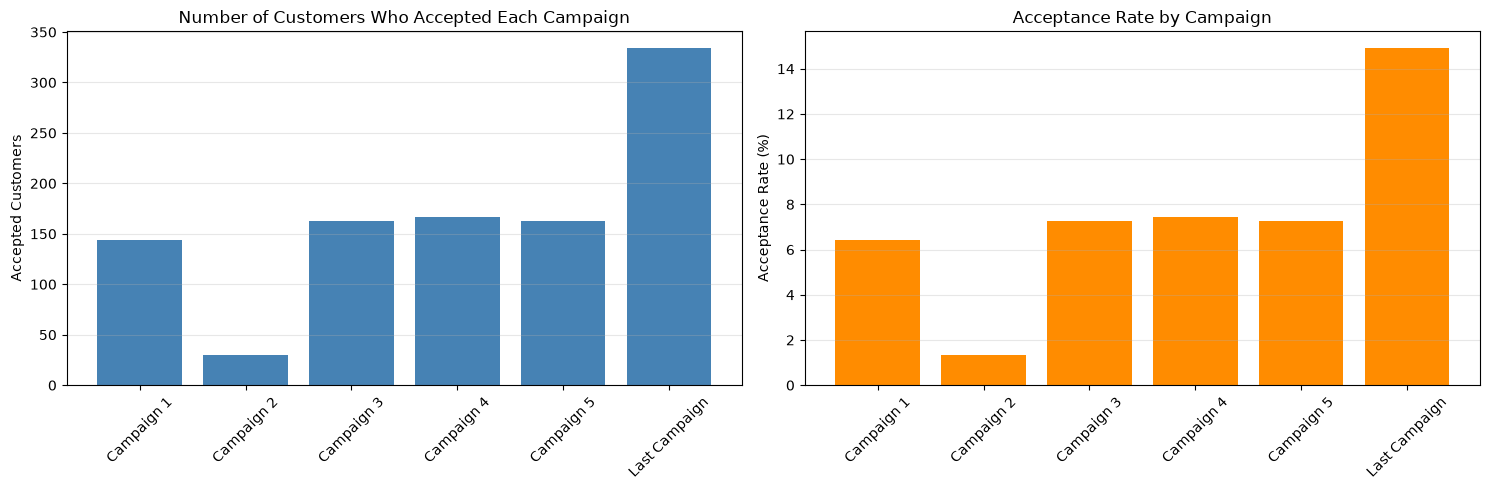

In [93]:
campaign_columns = [
    "AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3",
    "AcceptedCmp4", "AcceptedCmp5", "Response"
]
campaign_labels = ["Campaign 1", "Campaign 2", "Campaign 3", "Campaign 4", "Campaign 5", "Last Campaign"]

acceptance_counts = data[campaign_columns].sum()
acceptance_rates = data[campaign_columns].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].bar(campaign_labels, acceptance_counts, color="steelblue")
axes[0].set_title("Number of Customers Who Accepted Each Campaign")
axes[0].set_ylabel("Accepted Customers")
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(axis="y", alpha=0.3)

axes[1].bar(campaign_labels, acceptance_rates, color="darkorange")
axes[1].set_title("Acceptance Rate by Campaign")
axes[1].set_ylabel("Acceptance Rate (%)")
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [94]:
income_median = data["Income"].median()
data["Income"] = data["Income"].fillna(income_median)

print(f"Income median used for missing values: {income_median:,.2f}")
print(f"Remaining missing Income values: {data['Income'].isna().sum()}")

Income median used for missing values: 51,381.50
Remaining missing Income values: 0


In [95]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

segmentation_features = [
    "Income", "Recency", "Kidhome", "Teenhome",
    "MntWines", "MntFruits", "MntMeatProducts",
    "MntFishProducts", "MntSweetProducts", "MntGoldProds",
    "NumDealsPurchases", "NumWebPurchases",
    "NumCatalogPurchases", "NumStorePurchases",
    "NumWebVisitsMonth"
]

segmentation_data = data[segmentation_features].copy()
segmentation_data = segmentation_data.fillna(segmentation_data.median())
segmentation_scaled = StandardScaler().fit_transform(segmentation_data)

final_segmentation_model = KMeans(n_clusters=2, random_state=42, n_init=10)
data["Customer_Segment"] = final_segmentation_model.fit_predict(segmentation_scaled)

segment_profile = (
    data.groupby("Customer_Segment")[segmentation_features]
    .mean()
    .round(1)
)
segment_profile

,Income,Recency,Kidhome,Teenhome,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth
Customer_Segment,,,,,,,,,,,,,,,
0,39027.5,48.9,0.7,0.6,107.2,6.3,36.8,9.2,6.2,22.3,2.6,2.9,0.9,3.9,6.4
1,71834.1,49.5,0.1,0.4,595.7,56.0,359.9,79.6,58.0,76.2,2.0,5.8,5.3,8.5,3.7


In [96]:
customer_segment_summary

,Segment_Name,Customer_Count,Average_Income,Average_Recency,Average_Spending,Average_Purchases,Average_Web_Visits,Recommended_Action
Customer_Segment,,,,,,,,
0,Lower-value customers,1338,39027.5,48.9,188.0,7.8,6.4,Use personalized discounts and product education
1,High-value customers,902,71834.1,49.5,1225.5,19.6,3.7,Offer loyalty rewards and premium products
